In [1]:
!pip install opendatasets

In [2]:
!pip install xgboost

In [3]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.0 MB/s eta 0:00:00


In [4]:
import opendatasets as od

In [5]:
od.download("https://www.kaggle.com/datasets/wasiqaliyasir/breast-cancer-dataset")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: sneha
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/wasiqaliyasir/breast-cancer-dataset


100%|██████████| 48.7k/48.7k [00:00<00:00, 1.40MB/s]

In [6]:
import os

In [7]:
print(os.listdir())

['.config', 'breast-cancer-dataset', 'sample_data']


In [8]:
print(os.listdir('breast-cancer-dataset'))

['Breast_cancer_dataset.csv']


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import sklearn as sk
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB, CategoricalNB
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.feature_selection import RFE
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.svm import SVC

In [10]:
data = pd.read_csv('breast-cancer-dataset/Breast_cancer_dataset.csv')

In [11]:
data.head(3)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN


In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [13]:
data['diagnosis'] = np.where(data['diagnosis']=='B',0,1)

In [14]:
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [15]:
data['diagnosis'].value_counts()

,count
diagnosis,
0,357
1,212


In [16]:
for col in data.columns:
  if data[col].dtypes == 'int' or data[col].dtypes == 'object' or data[col].dtype == 'float':
    print(data[col].value_counts())


id
92751       1
842302      1
842517      1
84300903    1
84348301    1
           ..
846381      1
846226      1
84610002    1
845636      1
84501001    1
Name: count, Length: 569, dtype: int64
diagnosis
0    357
1    212
Name: count, dtype: int64
radius_mean
12.340    4
11.060    3
10.260    3
12.770    3
13.050    3
         ..
19.810    1
13.540    1
13.080    1
9.504     1
15.340    1
Name: count, Length: 456, dtype: int64
texture_mean
16.84    3
19.83    3
15.70    3
20.52    3
18.22    3
        ..
27.88    1
22.68    1
23.93    1
29.37    1
30.62    1
Name: count, Length: 479, dtype: int64
perimeter_mean
82.61     3
134.70    3
87.76     3
113.40    2
120.20    2
         ..
82.53     1
100.40    1
81.15     1
60.73     1
87.02     1
Name: count, Length: 522, dtype: int64
area_mean
512.2     3
321.6     2
582.7     2
1138.0    2
477.3     2
         ..
1148.0    1
642.7     1
461.0     1
951.6     1
477.4     1
Name: count, Length: 539, dtype: int64
smoothness_mean
0.10070    

In [17]:
def outliers_influence(x):
  x = x.clip(upper= x.quantile(0.99),lower= x.quantile(0.01))
  return x

In [18]:
data = data.apply(outliers_influence)

In [19]:
data.drop_duplicates

<bound method DataFrame.drop_duplicates of              id  diagnosis  radius_mean  texture_mean  perimeter_mean  \
0      842302.0          1     17.99000       10.9304        122.8000   
1      842517.0          1     20.57000       17.7700        132.9000   
2    84300903.0          1     19.69000       21.2500        130.0000   
3    84348301.0          1     11.42000       20.3800         77.5800   
4    84358402.0          1     20.29000       14.3400        135.1000   
..          ...        ...          ...           ...             ...   
564    926424.0          1     21.56000       22.3900        142.0000   
565    926682.0          1     20.13000       28.2500        131.2000   
566    926954.0          1     16.60000       28.0800        108.3000   
567    927241.0          1     20.60000       29.3300        140.1000   
568     92751.0          0      8.45836       24.5400         53.8276   

     area_mean  smoothness_mean  compactness_mean  concavity_mean  \
0     1001.000         0.118400          0.277192         0.30010   
1     1326.000         0.084740          0.078640         0.08690   
2     1203.000         0.109600          0.159900         0.19740   
3      386.100         0.132888          0.277192         0.24140   
4     1297.000         0.100300          0.132800         0.19800   
..         ...              ...               ...             ...   
564   1479.000         0.111000          0.115900         0.24390   
565   1261.000         0.097800          0.103400         0.14400   
566    858.100         0.084550          0.102300         0.09251   
567   1265.000         0.117800          0.277000         0.35140   
568    215.664         0.068654          0.043620         0.00000   

     concave points_mean  ...  texture_worst  perimeter_worst  area_worst  \
0                0.14710  ...          17.33           184.60      2019.0   
1                0.07017  ...          23.41           158.80      1956.0   
2                0.12790  ...          25.53           152.50      1709.0   
3                0.10520  ...          26.50            98.87       567.7   
4                0.10430  ...          16.67           152.20      1575.0   
..                   ...  ...            ...              ...         ...   
564              0.13890  ...          26.40           166.10      2027.0   
565              0.09791  ...          38.25           155.00      1731.0   
566              0.05302  ...          34.12           126.70      1124.0   
567              0.15200  ...          39.42           184.60      1821.0   
568              0.00000  ...          30.37            59.16       268.6   

     smoothness_worst  compactness_worst  concavity_worst  \
0            0.162200           0.665600          0.71190   
1            0.123800           0.186600          0.24160   
2            0.144400           0.424500          0.45040   
3            0.188908           0.778644          0.68690   
4            0.137400           0.205000          0.40000   
..                ...                ...              ...   
564          0.141000           0.211300          0.41070   
565          0.116600           0.192200          0.32150   
566          0.113900           0.309400          0.34030   
567          0.165000           0.778644          0.90238   
568          0.089960           0.064440          0.00000   

     concave points_worst  symmetry_worst  fractal_dimension_worst  \
0                  0.2654        0.460100                 0.118900   
1                  0.1860        0.275000                 0.089020   
2                  0.2430        0.361300                 0.087580   
3                  0.2575        0.486908                 0.140628   
4                  0.1625        0.236400                 0.076780   
..                    ...             ...                      ...   
564                0.2216        0.206000                 0.071150   
565                0.1628        

In [20]:
data

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302.0,1,17.99000,10.9304,122.8000,1001.000,0.118400,0.277192,0.30010,0.14710,...,17.33,184.60,2019.0,0.162200,0.665600,0.71190,0.2654,0.460100,0.118900,NaN
1,842517.0,1,20.57000,17.7700,132.9000,1326.000,0.084740,0.078640,0.08690,0.07017,...,23.41,158.80,1956.0,0.123800,0.186600,0.24160,0.1860,0.275000,0.089020,NaN
2,84300903.0,1,19.69000,21.2500,130.0000,1203.000,0.109600,0.159900,0.19740,0.12790,...,25.53,152.50,1709.0,0.144400,0.424500,0.45040,0.2430,0.361300,0.087580,NaN
3,84348301.0,1,11.42000,20.3800,77.5800,386.100,0.132888,0.277192,0.24140,0.10520,...,26.50,98.87,567.7,0.188908,0.778644,0.68690,0.2575,0.486908,0.140628,NaN
4,84358402.0,1,20.29000,14.3400,135.1000,1297.000,0.100300,0.132800,0.19800,0.10430,...,16.67,152.20,1575.0,0.137400,0.205000,0.40000,0.1625,0.236400,0.076780,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424.0,1,21.56000,22.3900,142.0000,1479.000,0.111000,0.115900,0.24390,0.13890,...,26.40,166.10,2027.0,0.141000,0.211300,0.41070,0.2216,0.206000,0.071150,NaN
565,926682.0,1,20.13000,28.2500,131.2000,1261.000,0.097800,0.103400,0.14400,0.09791,...,38.25,155.00,1731.0,0.116600,0.192200,0.32150,0.1628,0.257200,0.066370,NaN
566,926954.0,1,16.60000,28.0800,108.3000,858.100,0.084550,0.102300,0.09251,0.05302,...,34.12,126.70,1124.0,0.113900,0.309400,0.34030,0.1418,0.221800,0.078200,NaN
567,927241.0,1,20.60000,29.3300,140.1000,1265.000,0.117800,0.277000,0.35140,0.15200,...,39.42,184.60,1821.0,0.165000,0.778644,0.90238,0.2650,0.408700,0.124000,NaN


In [21]:
data.columns = data.columns.str.replace(' ','_')

In [22]:
data.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave_points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed:_32'],
      dtype='object')

In [23]:
data_trad = data[['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave_points_worst',
       'symmetry_worst', 'fractal_dimension_worst']]


In [24]:
x = data[['radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave_points_worst',
       'symmetry_worst', 'fractal_dimension_worst']]

In [25]:
y = data[['diagnosis']]

In [26]:
x.shape

(569, 30)

In [27]:
y.shape

(569, 1)

In [28]:
vif_data = pd.DataFrame()
vif_data["feature"] = x.columns
vif_data["VIF"] = [variance_inflation_factor(x.values, i) for i in range(len(x.columns))]


In [29]:
vif_data = vif_data.loc[vif_data['VIF']<=80,['feature']]

In [30]:
vif_data

,feature
11,texture_se
14,smoothness_se
15,compactness_se
16,concavity_se
17,concave_points_se
18,symmetry_se
19,fractal_dimension_se


In [31]:
vif_data['feature'].values

array(['texture_se', 'smoothness_se', 'compactness_se', 'concavity_se',
       'concave_points_se', 'symmetry_se', 'fractal_dimension_se'],
      dtype=object)

In [32]:
data_trad = data_trad[['texture_se', 'smoothness_se', 'compactness_se', 'concavity_se',
       'concave_points_se', 'symmetry_se', 'fractal_dimension_se','diagnosis']]

In [33]:
data_trad.head()

,texture_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,diagnosis
0,0.9053,0.006399,0.04904,0.05373,0.01587,0.030030,0.006193,1
1,0.7339,0.005225,0.01308,0.01860,0.01340,0.013890,0.003532,1
2,0.7869,0.006150,0.04006,0.03832,0.02058,0.022500,0.004571,1
3,1.1560,0.009110,0.07458,0.05661,0.01867,0.052208,0.009208,1
4,0.7813,0.011490,0.02461,0.05688,0.01885,0.017560,0.005115,1


In [34]:
train,test = train_test_split(data_trad,test_size=0.2,random_state=123)

In [35]:
feature = data_trad.columns.difference(['diagnosis'])
formula = 'diagnosis~'+'+'.join(feature)

In [36]:
formula

'diagnosis~compactness_se+concave_points_se+concavity_se+fractal_dimension_se+smoothness_se+symmetry_se+texture_se'

In [37]:
model1 = smf.logit(formula=formula,data=train).fit()

Optimization terminated successfully.
         Current function value: 0.495714
         Iterations 8


In [38]:
print(model1.summary())

                           Logit Regression Results                           
Dep. Variable:              diagnosis   No. Observations:                  455
Model:                          Logit   Df Residuals:                      447
Method:                           MLE   Df Model:                            7
Date:                Wed, 25 Mar 2026   Pseudo R-squ.:                  0.2512
Time:                        07:35:38   Log-Likelihood:                -225.55
converged:                       True   LL-Null:                       -301.20
Covariance Type:            nonrobust   LLR p-value:                 2.161e-29
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -0.8958      0.440     -2.036      0.042      -1.758      -0.033
compactness_se          21.5137     20.878      1.030      0.303     -19.406      62.433
concave_poin

In [39]:
model1.predict(train)

,0
190,0.227069
134,0.336955
386,0.413847
118,0.353393
316,0.133876
...,...
98,0.140118
322,0.324595
382,0.503776
365,0.704000


In [40]:
train['predected'] = np.where(model1.predict(train)>=0.5,1,0)
test['predected'] = np.where(model1.predict(test)>=0.5,1,0)


In [41]:
train['predected'].value_counts()
test['predected'].value_counts()

,count
predected,
0,90
1,24


In [42]:
print(classification_report(train['diagnosis'],train['predected']))

              precision    recall  f1-score   support

           0       0.79      0.86      0.82       284
           1       0.73      0.61      0.67       171

    accuracy                           0.77       455
   macro avg       0.76      0.74      0.75       455
weighted avg       0.77      0.77      0.76       455



In [43]:
print(classification_report(test['diagnosis'],test['predected']))

              precision    recall  f1-score   support

           0       0.76      0.93      0.83        73
           1       0.79      0.46      0.58        41

    accuracy                           0.76       114
   macro avg       0.77      0.70      0.71       114
weighted avg       0.77      0.76      0.74       114



In [44]:
# KNN
# naive bayes
# random forest
# decision tree
# bagging
# boosting


In [45]:
vif_data['feature'].values

array(['texture_se', 'smoothness_se', 'compactness_se', 'concavity_se',
       'concave_points_se', 'symmetry_se', 'fractal_dimension_se'],
      dtype=object)

In [46]:
x = data_trad[['texture_se', 'smoothness_se', 'compactness_se', 'concavity_se',
       'concave_points_se', 'symmetry_se', 'fractal_dimension_se']]

In [47]:
y = data_trad['diagnosis']

In [48]:
x

,texture_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se
0,0.9053,0.006399,0.049040,0.05373,0.01587,0.030030,0.006193
1,0.7339,0.005225,0.013080,0.01860,0.01340,0.013890,0.003532
2,0.7869,0.006150,0.040060,0.03832,0.02058,0.022500,0.004571
3,1.1560,0.009110,0.074580,0.05661,0.01867,0.052208,0.009208
4,0.7813,0.011490,0.024610,0.05688,0.01885,0.017560,0.005115
...,...,...,...,...,...,...,...
564,1.2560,0.010300,0.028910,0.05198,0.02454,0.011140,0.004239
565,2.4630,0.005769,0.024230,0.03950,0.01678,0.018980,0.002498
566,1.0750,0.005903,0.037310,0.04730,0.01557,0.013180,0.003892
567,1.5950,0.006522,0.061580,0.07117,0.01664,0.023240,0.006185


In [49]:
y

,diagnosis
0,1
1,1
2,1
3,1
4,1
...,...
564,1
565,1
566,1
567,1


In [50]:
std = StandardScaler()

In [51]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=123)

In [52]:
x_train.shape

(455, 7)

In [53]:
x_test.shape

(114, 7)

In [54]:
y_train.shape

(455,)

In [55]:
y_test.shape

(114,)

In [56]:
x_train.head()

,texture_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se
190,2.1100,0.007970,0.089872,0.11660,0.016660,0.05113,0.011720
134,1.2020,0.006001,0.014220,0.02855,0.009148,0.01492,0.002205
386,0.8309,0.004405,0.030260,0.04344,0.010870,0.01921,0.004622
118,1.0720,0.008699,0.039760,0.05950,0.013900,0.01495,0.005984
316,0.5996,0.005343,0.005767,0.01123,0.005051,0.01977,0.001114


In [57]:
y_train.head()

,diagnosis
190,1
134,1
386,0
118,1
316,0


In [58]:
std = StandardScaler()

In [59]:
std.fit(x_train)

StandardScaler()

In [60]:
std.transform(x_train)
std.transform(x_test)

array([[-4.22927433e-01, -5.16871263e-01, -1.06862170e+00,
        -1.28718003e+00, -1.55008766e+00, -4.70779131e-01,
        -7.90921781e-01],
       [ 3.70495529e-01,  2.49540400e+00, -8.67138711e-01,
        -9.78168807e-01, -4.33113163e-01, -3.45779926e-01,
         2.14160101e-01],
       [-7.45561763e-01, -3.42753434e-01, -1.37054285e-02,
        -1.90982906e-01,  2.47230516e-01, -6.05982352e-01,
        -5.08003169e-01],
       [-1.42567999e-01, -1.32635352e+00, -1.20605514e+00,
        -1.26114167e+00, -1.73633559e+00, -5.81747813e-01,
        -1.20380275e+00],
       [ 4.97320221e-01, -2.02502074e-01, -5.36447519e-01,
        -1.52007083e-01,  3.75500440e-01,  3.83807269e-01,
        -1.37966141e-02],
       [-7.18467397e-01, -1.06683329e+00, -4.39853872e-01,
        -4.91473931e-01, -3.35970074e-01, -1.29347798e+00,
        -2.47159418e-01],
       [ 6.66419810e-01,  6.81339172e-01,  9.08479803e-01,
         1.16395082e+00,  9.99747405e-01,  9.23344653e-01,
         4.4572087

In [61]:
x_train_std = pd.DataFrame(std.transform(x_train))


In [62]:
x_test_std = pd.DataFrame(std.transform(x_test))

In [63]:
KNeighborsClassifier?

In [64]:
par_grid = {'n_neighbors':[30,35,40,45,50], 'weights':['uniform','distance']}

In [65]:
grid_knn = GridSearchCV(KNeighborsClassifier(),param_grid= par_grid, cv=5)

In [66]:
grid_knn = grid_knn.fit(x_train_std,y_train)

In [67]:
grid_knn.best_params_

{'n_neighbors': 35, 'weights': 'distance'}

In [68]:
grid_knn.best_score_

np.float64(0.7846153846153847)

In [69]:
grid_knn.best_estimator_

KNeighborsClassifier(n_neighbors=35, weights='distance')

In [70]:
knn =grid_knn.best_estimator_

In [71]:
knn = knn.fit(x_train_std,y_train)

In [72]:
knn.predict(x_train_std)

array([1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,

In [73]:
print(classification_report(y_train,knn.predict(x_train_std)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       284
           1       1.00      1.00      1.00       171

    accuracy                           1.00       455
   macro avg       1.00      1.00      1.00       455
weighted avg       1.00      1.00      1.00       455



In [74]:
print(classification_report(y_test,knn.predict(x_test_std)))

              precision    recall  f1-score   support

           0       0.81      0.82      0.82        73
           1       0.68      0.66      0.67        41

    accuracy                           0.76       114
   macro avg       0.74      0.74      0.74       114
weighted avg       0.76      0.76      0.76       114



In [75]:
x_train

,texture_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se
190,2.1100,0.007970,0.089872,0.11660,0.016660,0.05113,0.011720
134,1.2020,0.006001,0.014220,0.02855,0.009148,0.01492,0.002205
386,0.8309,0.004405,0.030260,0.04344,0.010870,0.01921,0.004622
118,1.0720,0.008699,0.039760,0.05950,0.013900,0.01495,0.005984
316,0.5996,0.005343,0.005767,0.01123,0.005051,0.01977,0.001114
...,...,...,...,...,...,...,...
98,0.5391,0.006153,0.013300,0.01693,0.006884,0.01651,0.002551
322,1.0420,0.005910,0.020160,0.01902,0.010110,0.01202,0.003107
382,1.4340,0.005042,0.045600,0.04305,0.016670,0.02470,0.007358
365,0.9168,0.006208,0.019060,0.02375,0.014610,0.01445,0.001906


In [76]:
y_test

,diagnosis
333,0
273,0
201,1
178,0
85,1
...,...
179,0
192,0
246,0
211,0


In [77]:
# KNN-----done
# naive bayes
# random forest
# decision tree
# bagging
# boosting

In [78]:
GaussianNB?

In [79]:
par_grid_nb = {'n_features_in_':[25,30,35,40,45,50]}

In [80]:
grid_cv_nb = GridSearchCV(GaussianNB(),param_grid={},cv=5)

In [81]:
grid_cv_nb=grid_cv_nb.fit(x_train,y_train)

In [82]:
grid_cv_nb.best_estimator_

GaussianNB()

In [83]:
grid_cv_nb.best_score_

np.float64(0.7098901098901099)

In [84]:
grid_cv_nb.best_params_

{}

In [85]:
gb = grid_cv_nb.best_estimator_

In [86]:
gb=gb.fit(x_train,y_train)

In [87]:
gb.predict(x_train)

array([1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,

In [88]:
print(classification_report(y_train,gb.predict(x_train)))

              precision    recall  f1-score   support

           0       0.73      0.86      0.79       284
           1       0.67      0.48      0.56       171

    accuracy                           0.71       455
   macro avg       0.70      0.67      0.67       455
weighted avg       0.71      0.71      0.70       455



In [89]:
print(classification_report(y_test,gb.predict(x_test)))

              precision    recall  f1-score   support

           0       0.74      0.89      0.81        73
           1       0.69      0.44      0.54        41

    accuracy                           0.73       114
   macro avg       0.72      0.66      0.67       114
weighted avg       0.72      0.73      0.71       114



In [90]:
# KNN-----done
# naive bayes----done
# random forest
# decision tree
# bagging
# boosting

In [91]:
RandomForestClassifier?

In [92]:
par_grid_rf = {'n_estimators' : [50,100,150], 'max_depth' : np.arange(3,11), 'max_features':np.arange(3,11),
             'max_leaf_nodes':np.arange(3,11),'oob_score':[True]}

In [93]:
grid_cv_rf = GridSearchCV(RandomForestClassifier(),param_grid={},cv=5,n_jobs=-1)

In [94]:
grid_cv_rf = grid_cv_rf.fit(x_train,y_train)

In [95]:
grid_cv_rf.best_params_

{}

In [96]:
grid_cv_rf.best_estimator_

RandomForestClassifier()

In [97]:
grid_cv_rf.best_score_

np.float64(0.7912087912087913)

In [98]:
rf = grid_cv_rf.best_estimator_

In [99]:
rf = rf.fit(x_train,y_train)

In [100]:
rf.predict(x_train)

array([1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,

In [101]:
print(classification_report(y_train,rf.predict(x_train)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       284
           1       1.00      1.00      1.00       171

    accuracy                           1.00       455
   macro avg       1.00      1.00      1.00       455
weighted avg       1.00      1.00      1.00       455



In [102]:
print(classification_report(y_test,rf.predict(x_test)))

              precision    recall  f1-score   support

           0       0.81      0.92      0.86        73
           1       0.81      0.61      0.69        41

    accuracy                           0.81       114
   macro avg       0.81      0.76      0.78       114
weighted avg       0.81      0.81      0.80       114



In [103]:
# KNN-----done
# naive bayes----done
# random forest-----done
# decision tree
# bagging
# boosting

In [104]:
DecisionTreeClassifier?

In [105]:
par_grid_dt = {'max_depth':[2,3,4,5], 'max_features':[2,3,4], 'max_leaf_nodes':[2,3,4,5,6,7,8]}

In [106]:
grid_cv_dt = GridSearchCV(DecisionTreeClassifier(),param_grid=par_grid_dt,cv=5)

In [107]:
grid_cv_dt= grid_cv_dt.fit(x_train,y_train)

In [108]:
grid_cv_dt.best_params_

{'max_depth': 3, 'max_features': 4, 'max_leaf_nodes': 6}

In [109]:
grid_cv_dt.best_estimator_

DecisionTreeClassifier(max_depth=3, max_features=4, max_leaf_nodes=6)

In [110]:
grid_cv_dt.best_score_

np.float64(0.7626373626373626)

In [111]:
dt = grid_cv_dt.best_estimator_

In [112]:
dt = dt.fit(x_train,y_train)

In [113]:
print(classification_report(y_train,dt.predict(x_train)))

              precision    recall  f1-score   support

           0       0.80      0.84      0.82       284
           1       0.71      0.65      0.68       171

    accuracy                           0.77       455
   macro avg       0.76      0.75      0.75       455
weighted avg       0.77      0.77      0.77       455



In [114]:
print(classification_report(y_test,dt.predict(x_test)))

              precision    recall  f1-score   support

           0       0.72      0.86      0.78        73
           1       0.62      0.39      0.48        41

    accuracy                           0.69       114
   macro avg       0.67      0.63      0.63       114
weighted avg       0.68      0.69      0.67       114



In [115]:
# KNN-----done
# naive bayes----done
# random forest-----done
# decision tree------done
# bagging
# boosting

In [116]:
BaggingClassifier?

In [117]:
par_grid_bag = {'n_estimators':[50,100], 'max_samples':[50,100,150], 'max_features':list(range(1,8)), 'oob_score':[True]}

In [118]:
grid_cv_bag = GridSearchCV(BaggingClassifier(),param_grid=par_grid_bag,cv=5,n_jobs=-1)

In [119]:
grid_cv_bag = grid_cv_bag.fit(x_train,y_train)

In [120]:
grid_cv_bag.best_params_

{'max_features': 7, 'max_samples': 150, 'n_estimators': 100, 'oob_score': True}

In [121]:
grid_cv_bag.best_estimator_

BaggingClassifier(max_features=7, max_samples=150, n_estimators=100,
                  oob_score=True)

In [122]:
grid_cv_bag.best_score_

np.float64(0.8021978021978022)

In [123]:
bag = grid_cv_bag.best_estimator_

In [124]:
bag = bag.fit(x_train,y_train)

In [125]:
print(classification_report(y_train,bag.predict(x_train)))

              precision    recall  f1-score   support

           0       0.93      0.94      0.94       284
           1       0.90      0.88      0.89       171

    accuracy                           0.92       455
   macro avg       0.92      0.91      0.92       455
weighted avg       0.92      0.92      0.92       455



In [126]:
print(classification_report(y_test,bag.predict(x_test)))

              precision    recall  f1-score   support

           0       0.79      0.89      0.84        73
           1       0.75      0.59      0.66        41

    accuracy                           0.78       114
   macro avg       0.77      0.74      0.75       114
weighted avg       0.78      0.78      0.77       114



In [127]:
# KNN-----done
# naive bayes----done
# random forest-----done
# decision tree------done
# bagging----done
# boosting----xgboost, catboost

In [128]:
XGBClassifier?

In [129]:
par_grid_xgb = {'n_estimators':[50,100,150], 'max_depth':[2,3,4,5],'learning_rate':[0.001,0.01]}

In [130]:
grid_cv_xgb = GridSearchCV(XGBClassifier(),param_grid=par_grid_xgb,cv=5,n_jobs=-1)

In [131]:
grid_cv_xgb = grid_cv_xgb.fit(x_train,y_train)

In [132]:
grid_cv_xgb.best_params_

{'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 150}

In [133]:
grid_cv_xgb.best_estimator_

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=150,
              n_jobs=None, num_parallel_tree=None, ...)

In [134]:
grid_cv_xgb.best_score_

np.float64(0.7780219780219781)

In [135]:
xgb = grid_cv_xgb.best_estimator_

In [136]:
xgb = xgb.fit(x_train,y_train)

In [137]:
print(classification_report(y_train,xgb.predict(x_train)))

              precision    recall  f1-score   support

           0       0.92      0.89      0.91       284
           1       0.83      0.87      0.85       171

    accuracy                           0.88       455
   macro avg       0.87      0.88      0.88       455
weighted avg       0.89      0.88      0.88       455



In [138]:
print(classification_report(y_test,xgb.predict(x_test)))

              precision    recall  f1-score   support

           0       0.80      0.89      0.84        73
           1       0.76      0.61      0.68        41

    accuracy                           0.79       114
   macro avg       0.78      0.75      0.76       114
weighted avg       0.79      0.79      0.78       114



In [139]:
LGBMClassifier?

In [140]:
par_grid_lgb = {'n_estimators':[100,150,200], 'max_depth':[2,3,4], 'learning_rate':[0.001,0.01]}

In [141]:
grid_cv_light = GridSearchCV(LGBMClassifier(),param_grid=par_grid_lgb, cv=5,n_jobs=-1)

In [142]:
grid_cv_light = grid_cv_light.fit(x_train,y_train)

[LightGBM] [Info] Number of positive: 171, number of negative: 284
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000087 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1058
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.375824 -> initscore=-0.507311
[LightGBM] [Info] Start training from score -0.507311
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

In [143]:
grid_cv_light.best_estimator_

LGBMClassifier(learning_rate=0.01, max_depth=4, n_estimators=200)

In [144]:
grid_cv_light.best_params_

{'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 200}

In [145]:
grid_cv_light.best_score_

np.float64(0.7670329670329671)

In [146]:
light = grid_cv_light.best_estimator_

In [147]:
light = light.fit(x_train,y_train)

[LightGBM] [Info] Number of positive: 171, number of negative: 284
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000179 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1058
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.375824 -> initscore=-0.507311
[LightGBM] [Info] Start training from score -0.507311
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

In [148]:
light.predict(x_train)

array([1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,

In [149]:
print(classification_report(y_train,light.predict(x_train)))

              precision    recall  f1-score   support

           0       0.92      0.87      0.90       284
           1       0.81      0.88      0.84       171

    accuracy                           0.87       455
   macro avg       0.86      0.88      0.87       455
weighted avg       0.88      0.87      0.88       455



In [150]:
print(classification_report(y_test,light.predict(x_test)))

              precision    recall  f1-score   support

           0       0.79      0.86      0.82        73
           1       0.71      0.59      0.64        41

    accuracy                           0.76       114
   macro avg       0.75      0.72      0.73       114
weighted avg       0.76      0.76      0.76       114



In [151]:
# KNN-----done
# naive bayes----done
# random forest-----done
# decision tree------done
# bagging----done
# boosting----xgboost, catboost

In [152]:
CatBoostClassifier?

In [153]:
par_grid_cat = {'iterations':[10],'learning_rate':[0.001,0.01]}

In [154]:
grid_cv_cat = GridSearchCV(CatBoostClassifier(),param_grid=par_grid_cat,cv=5,n_jobs=-1)

In [155]:
grid_cv_cat = grid_cv_cat.fit(x_train,y_train)

0:	learn: 0.6929292	total: 48.5ms	remaining: 437ms
1:	learn: 0.6926785	total: 50.7ms	remaining: 203ms
2:	learn: 0.6924211	total: 52.6ms	remaining: 123ms
3:	learn: 0.6921953	total: 54.3ms	remaining: 81.5ms
4:	learn: 0.6919604	total: 56.2ms	remaining: 56.2ms
5:	learn: 0.6917333	total: 57.9ms	remaining: 38.6ms
6:	learn: 0.6914637	total: 59.7ms	remaining: 25.6ms
7:	learn: 0.6912556	total: 61.4ms	remaining: 15.4ms
8:	learn: 0.6909795	total: 63.2ms	remaining: 7.02ms
9:	learn: 0.6907297	total: 65ms	remaining: 0us


In [156]:
grid_cv_cat.best_params_

{'iterations': 10, 'learning_rate': 0.001}

In [157]:
grid_cv_cat.best_estimator_

CatBoostClassifier(iterations=10, learning_rate=0.001)

In [158]:
grid_cv_cat.best_score_

np.float64(0.7692307692307692)

In [159]:
cat_boost = grid_cv_cat.best_estimator_

In [160]:
cat_boost = cat_boost.fit(x_train,y_train)

0:	learn: 0.6929292	total: 2.01ms	remaining: 18.1ms
1:	learn: 0.6926785	total: 3.89ms	remaining: 15.6ms
2:	learn: 0.6924211	total: 7.68ms	remaining: 17.9ms
3:	learn: 0.6921953	total: 9.46ms	remaining: 14.2ms
4:	learn: 0.6919604	total: 12.9ms	remaining: 12.9ms
5:	learn: 0.6917333	total: 14.7ms	remaining: 9.78ms
6:	learn: 0.6914637	total: 16.4ms	remaining: 7.03ms
7:	learn: 0.6912556	total: 18.2ms	remaining: 4.55ms
8:	learn: 0.6909795	total: 20ms	remaining: 2.22ms
9:	learn: 0.6907297	total: 21.7ms	remaining: 0us


In [161]:
print(classification_report(y_train,cat_boost.predict(x_train)))

              precision    recall  f1-score   support

           0       0.87      0.77      0.82       284
           1       0.68      0.81      0.74       171

    accuracy                           0.78       455
   macro avg       0.78      0.79      0.78       455
weighted avg       0.80      0.78      0.79       455



In [162]:
print(classification_report(y_test,cat_boost.predict(x_test)))

              precision    recall  f1-score   support

           0       0.84      0.85      0.84        73
           1       0.72      0.71      0.72        41

    accuracy                           0.80       114
   macro avg       0.78      0.78      0.78       114
weighted avg       0.80      0.80      0.80       114



In [163]:
# KNN-----done
# naive bayes----done
# random forest-----done
# decision tree------done
# bagging----done
# boosting----xgboost, catboost

In [164]:
grid_knn.best_score_

np.float64(0.7846153846153847)

In [165]:
grid_cv_xgb.best_score_

np.float64(0.7780219780219781)

In [166]:
grid_cv_rf.best_score_

np.float64(0.7912087912087913)

In [167]:
grid_cv_nb.best_score_

np.float64(0.7098901098901099)

In [168]:
grid_cv_light.best_score_

np.float64(0.7670329670329671)

In [169]:
grid_cv_dt.best_score_

np.float64(0.7626373626373626)

In [170]:
grid_cv_cat.best_score_

np.float64(0.7692307692307692)

In [171]:
grid_cv_bag.best_score_

np.float64(0.8021978021978022)

In [172]:
score = pd.DataFrame([grid_knn.best_score_,grid_cv_xgb.best_score_,grid_cv_rf.best_score_,grid_cv_nb.best_score_,grid_cv_light.best_score_,grid_cv_dt.best_score_,grid_cv_cat.best_score_,grid_cv_bag.best_score_])

In [173]:
name = pd.DataFrame(['knn','xgb','rf','nb','light','dt','cat','bag'])

In [174]:
best_score = pd.concat([name,score],axis=1)

In [175]:
best_score.columns = ['model','score']

In [176]:
best_score

,model,score
0,knn,0.784615
1,xgb,0.778022
2,rf,0.791209
3,nb,0.709890
4,light,0.767033
5,dt,0.762637
6,cat,0.769231
7,bag,0.802198


In [177]:
import joblib

In [178]:
joblib.dump(grid_cv_rf,"rf.pkl")

['rf.pkl']

In [179]:
joblib.load('rf.pkl')

GridSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1, param_grid={})

In [180]:
# in jupyter notebook
# joblib.dump(grid_cv_rf,"C:\Users\sneha\anaconda_practice\rf.pkl")
# joblib.load("C:\Users\sneha\anaconda_practice\rf.pkl")

In [181]:
rf_pkl = joblib.load('rf.pkl')

In [182]:
rf_pkl.predict(x_test)

array([0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1])

In [183]:
# svm and voting

In [184]:
estimator = []

In [185]:
grid_knn.best_params_

{'n_neighbors': 35, 'weights': 'distance'}

In [186]:
grid_cv_rf.best_params_

{}

In [187]:
grid_cv_nb.best_params_

{}

In [188]:
grid_cv_light.best_params_

{'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 200}

In [189]:
grid_cv_dt.best_params_

{'max_depth': 3, 'max_features': 4, 'max_leaf_nodes': 6}

In [190]:
grid_cv_xgb.best_params_

{'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 150}

In [191]:
grid_cv_cat.best_params_

{'iterations': 10, 'learning_rate': 0.001}

In [192]:
grid_cv_bag.best_params_

{'max_features': 7, 'max_samples': 150, 'n_estimators': 100, 'oob_score': True}

In [193]:
estimator = []
estimator.append(('knn',KNeighborsClassifier(n_neighbors = 35, weights='distance')))
estimator.append(('nb',GaussianNB()))
estimator.append(('rf',RandomForestClassifier()))
estimator.append(('dt',DecisionTreeClassifier(max_depth = 5, max_features = 4, max_leaf_nodes = 6)))
estimator.append(('bag',BaggingClassifier(max_features= 5, max_samples= 150, n_estimators= 50, oob_score= True)))
estimator.append(('xgb',XGBClassifier(learning_rate= 0.01, max_depth= 4, n_estimators= 150)))
estimator.append(('light',LGBMClassifier(learning_rate=0.01, max_depth= 4, n_estimators= 200)))
estimator.append(('cat',CatBoostClassifier(iterations= 10, learning_rate= 0.001)))

In [194]:
estimator

[('knn', KNeighborsClassifier(n_neighbors=35, weights='distance')),
 ('nb', GaussianNB()),
 ('rf', RandomForestClassifier()),
 ('dt', DecisionTreeClassifier(max_depth=5, max_features=4, max_leaf_nodes=6)),
 ('bag',
  BaggingClassifier(max_features=5, max_samples=150, n_estimators=50,
                    oob_score=True)),
 ('xgb',
  XGBClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bynode=None,
                colsample_bytree=None, device=None, early_stopping_rounds=None,
                enable_categorical=False, eval_metric=None, feature_types=None,
                feature_weights=None, gamma=None, grow_policy=None,
                importance_type=None, interaction_constraints=None,
                learning_rate=0.01, max_bin=None, max_cat_threshold=None,
                max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
                max_leaves=None, min_child_weight=None, missing=nan,
                monotone_cons

In [195]:
voting = VotingClassifier(estimators=estimator,voting='hard')

In [196]:
voting = voting.fit(x_train,y_train)

[LightGBM] [Info] Number of positive: 171, number of negative: 284
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000079 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1058
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.375824 -> initscore=-0.507311
[LightGBM] [Info] Start training from score -0.507311
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

In [197]:
voting.predict(x_test)

array([0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1])

In [198]:
print(classification_report(y_test,voting.predict(x_test)))

              precision    recall  f1-score   support

           0       0.80      0.90      0.85        73
           1       0.77      0.59      0.67        41

    accuracy                           0.79       114
   macro avg       0.78      0.74      0.76       114
weighted avg       0.79      0.79      0.78       114



In [199]:
print(classification_report(y_train,voting.predict(x_train)))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93       284
           1       0.89      0.89      0.89       171

    accuracy                           0.92       455
   macro avg       0.91      0.91      0.91       455
weighted avg       0.92      0.92      0.92       455



In [232]:
# for more accuracy for voting
# if votingclassifier gives you better score u can save it to pkl file

In [216]:
VotingClassifier?

In [222]:
par_grid_voting = {'voting':['hard','soft']}

In [223]:
grid_cv_voting = GridSearchCV(VotingClassifier(estimators=estimator),param_grid=par_grid_voting,cv=5,n_jobs=-1)

In [224]:
grid_cv_voting = grid_cv_voting.fit(x_train,y_train)

[LightGBM] [Info] Number of positive: 171, number of negative: 284
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000113 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1058
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.375824 -> initscore=-0.507311
[LightGBM] [Info] Start training from score -0.507311
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

In [225]:
grid_cv_voting.best_params_

{'voting': 'hard'}

In [226]:
grid_cv_voting.best_estimator_

VotingClassifier(estimators=[('knn',
                              KNeighborsClassifier(n_neighbors=35,
                                                   weights='distance')),
                             ('nb', GaussianNB()),
                             ('rf', RandomForestClassifier()),
                             ('dt',
                              DecisionTreeClassifier(max_depth=5,
                                                     max_features=4,
                                                     max_leaf_nodes=6)),
                             ('bag',
                              BaggingClassifier(max_features=5, max_samples=150,
                                                n_estimators=50,
                                                oob_score=True)),
                             ('xgb',
                              XGBClassifier(base_score=None, boos...
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=4,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=150, n_jobs=None,
                                            num_parallel_tree=None, ...)),
                             ('light',
                              LGBMClassifier(learning_rate=0.01, max_depth=4,
                                             n_estimators=200)),
                             ('cat',
                              CatBoostClassifier(iterations=10, learning_rate=0.001))])

In [227]:
grid_cv_voting.best_score_

np.float64(0.7802197802197801)

In [228]:
voting2 = grid_cv_voting.best_estimator_

In [229]:
voting2 = voting2.fit(x_train,y_train)

[LightGBM] [Info] Number of positive: 171, number of negative: 284
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000114 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1058
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.375824 -> initscore=-0.507311
[LightGBM] [Info] Start training from score -0.507311
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

In [230]:
print(classification_report(y_train,voting2.predict(x_train)))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94       284
           1       0.90      0.90      0.90       171

    accuracy                           0.93       455
   macro avg       0.92      0.92      0.92       455
weighted avg       0.93      0.93      0.93       455



In [231]:
print(classification_report(y_test,voting2.predict(x_test)))

              precision    recall  f1-score   support

           0       0.78      0.88      0.83        73
           1       0.72      0.56      0.63        41

    accuracy                           0.76       114
   macro avg       0.75      0.72      0.73       114
weighted avg       0.76      0.76      0.76       114



In [200]:
#### Unsupervised
# we should std 1st
# k-mean, silhoutte_score, elbow_method, inertia, PCA

In [255]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [241]:
od.download("https://www.kaggle.com/datasets/wasiqaliyasir/breast-cancer-dataset")

Skipping, found downloaded files in "./breast-cancer-dataset" (use force=True to force download)


In [242]:
data

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99000,10.9304,122.8000,1001.000,0.118400,0.277192,0.30010,0.14710,0.241900,...,25.380,17.33,184.60,2019.0,0.162200,0.665600,0.71190,0.2654,0.460100,0.118900
1,1,20.57000,17.7700,132.9000,1326.000,0.084740,0.078640,0.08690,0.07017,0.181200,...,24.990,23.41,158.80,1956.0,0.123800,0.186600,0.24160,0.1860,0.275000,0.089020
2,1,19.69000,21.2500,130.0000,1203.000,0.109600,0.159900,0.19740,0.12790,0.206900,...,23.570,25.53,152.50,1709.0,0.144400,0.424500,0.45040,0.2430,0.361300,0.087580
3,1,11.42000,20.3800,77.5800,386.100,0.132888,0.277192,0.24140,0.10520,0.259564,...,14.910,26.50,98.87,567.7,0.188908,0.778644,0.68690,0.2575,0.486908,0.140628
4,1,20.29000,14.3400,135.1000,1297.000,0.100300,0.132800,0.19800,0.10430,0.180900,...,22.540,16.67,152.20,1575.0,0.137400,0.205000,0.40000,0.1625,0.236400,0.076780
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,1,21.56000,22.3900,142.0000,1479.000,0.111000,0.115900,0.24390,0.13890,0.172600,...,25.450,26.40,166.10,2027.0,0.141000,0.211300,0.41070,0.2216,0.206000,0.071150
565,1,20.13000,28.2500,131.2000,1261.000,0.097800,0.103400,0.14400,0.09791,0.175200,...,23.690,38.25,155.00,1731.0,0.116600,0.192200,0.32150,0.1628,0.257200,0.066370
566,1,16.60000,28.0800,108.3000,858.100,0.084550,0.102300,0.09251,0.05302,0.159000,...,18.980,34.12,126.70,1124.0,0.113900,0.309400,0.34030,0.1418,0.221800,0.078200
567,1,20.60000,29.3300,140.1000,1265.000,0.117800,0.277000,0.35140,0.15200,0.239700,...,25.740,39.42,184.60,1821.0,0.165000,0.778644,0.90238,0.2650,0.408700,0.124000


In [237]:
data_uns = data

In [238]:
data_uns.drop(columns=['id','Unnamed:_32','diagnosis'], inplace=True)

KeyError: "['id', 'Unnamed:_32'] not found in axis"

In [245]:
# think that there is no diagonisis column in data we have to train all data so no y column is given

data_uns.drop(columns=['diagnosis'], inplace=True)

KeyError: "['diagnosis'] not found in axis"

In [244]:
data_uns

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,17.99000,10.9304,122.8000,1001.000,0.118400,0.277192,0.30010,0.14710,0.241900,0.078710,...,25.380,17.33,184.60,2019.0,0.162200,0.665600,0.71190,0.2654,0.460100,0.118900
1,20.57000,17.7700,132.9000,1326.000,0.084740,0.078640,0.08690,0.07017,0.181200,0.056670,...,24.990,23.41,158.80,1956.0,0.123800,0.186600,0.24160,0.1860,0.275000,0.089020
2,19.69000,21.2500,130.0000,1203.000,0.109600,0.159900,0.19740,0.12790,0.206900,0.059990,...,23.570,25.53,152.50,1709.0,0.144400,0.424500,0.45040,0.2430,0.361300,0.087580
3,11.42000,20.3800,77.5800,386.100,0.132888,0.277192,0.24140,0.10520,0.259564,0.085438,...,14.910,26.50,98.87,567.7,0.188908,0.778644,0.68690,0.2575,0.486908,0.140628
4,20.29000,14.3400,135.1000,1297.000,0.100300,0.132800,0.19800,0.10430,0.180900,0.058830,...,22.540,16.67,152.20,1575.0,0.137400,0.205000,0.40000,0.1625,0.236400,0.076780
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56000,22.3900,142.0000,1479.000,0.111000,0.115900,0.24390,0.13890,0.172600,0.056230,...,25.450,26.40,166.10,2027.0,0.141000,0.211300,0.41070,0.2216,0.206000,0.071150
565,20.13000,28.2500,131.2000,1261.000,0.097800,0.103400,0.14400,0.09791,0.175200,0.055330,...,23.690,38.25,155.00,1731.0,0.116600,0.192200,0.32150,0.1628,0.257200,0.066370
566,16.60000,28.0800,108.3000,858.100,0.084550,0.102300,0.09251,0.05302,0.159000,0.056480,...,18.980,34.12,126.70,1124.0,0.113900,0.309400,0.34030,0.1418,0.221800,0.078200
567,20.60000,29.3300,140.1000,1265.000,0.117800,0.277000,0.35140,0.15200,0.239700,0.070160,...,25.740,39.42,184.60,1821.0,0.165000,0.778644,0.90238,0.2650,0.408700,0.124000


In [233]:
std = StandardScaler()

In [246]:
std = std.fit(data_uns)

In [250]:
data_uns.columns

Index(['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
       'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave_points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [251]:
data_uns_std = pd.DataFrame(std.transform(data_uns),columns=['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
       'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave_points_worst',
       'symmetry_worst', 'fractal_dimension_worst'])

In [252]:
data_uns_std

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,1.127991,-1.989206,1.302472,1.044931,1.631561,3.337477,2.713092,2.589784,2.294185,2.379818,...,1.921392,-1.390271,2.348102,2.087450,1.352316,2.722141,2.179643,2.309060,2.923235,2.056578
1,1.878697,-0.356510,1.728058,2.016044,-0.854015,-0.492962,-0.018819,0.565287,0.004182,-0.902242,...,1.839294,-0.375459,1.566081,1.972386,-0.381653,-0.437939,-0.143126,1.094247,-0.247959,0.307403
2,1.622642,0.474209,1.605860,1.648515,0.981737,1.074695,1.397111,2.084515,0.973755,-0.407848,...,1.540373,-0.021610,1.375123,1.521264,0.548549,1.131545,0.888118,1.966342,1.230561,0.223106
3,-0.783691,0.266529,-0.602974,-0.792414,2.701407,3.337477,1.960920,1.487140,2.960587,3.381651,...,-0.282624,0.140293,-0.250450,-0.563217,2.558328,3.467920,2.056170,2.188191,3.382518,3.328535
4,1.797225,-1.175292,1.820760,1.929391,0.294991,0.551886,1.404799,1.463455,-0.007136,-0.580588,...,1.323550,-1.500432,1.366029,1.276525,0.232461,-0.316550,0.639197,0.734699,-0.909266,-0.409126
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,2.166758,0.746341,2.111507,2.473214,1.085118,0.225853,1.992955,2.373992,-0.320267,-0.967764,...,1.936127,0.123602,1.787351,2.102061,0.395021,-0.274987,0.692043,1.638924,-1.430089,-0.738706
565,1.750669,2.145194,1.656425,1.821821,0.110382,-0.015295,0.712852,1.295295,-0.222178,-1.101787,...,1.565634,2.101484,1.450900,1.561445,-0.706772,-0.400994,0.251493,0.739289,-0.552914,-1.018528
566,0.723540,2.104613,0.691482,0.617941,-0.868046,-0.036516,0.053067,0.113966,-0.833348,-0.930536,...,0.574143,1.412146,0.593102,0.452814,-0.828692,0.372203,0.344344,0.417991,-1.159398,-0.325999
567,1.887426,2.403004,2.031446,1.833773,1.587255,3.333773,3.370442,2.718733,2.211186,1.106605,...,1.997174,2.296768,2.348102,1.725821,1.478752,3.467920,3.120406,2.302940,2.042633,2.355132


In [256]:
# for better u can use gridsearchcv
KMeans?

In [257]:
k_mean = KMeans(n_clusters=4, random_state=123)

In [258]:
kmean = k_mean.fit(data_uns_std)

In [262]:
kmean.predict(data_uns_std)

array([2, 0, 2, 3, 2, 3, 0, 3, 3, 3, 0, 0, 2, 0, 3, 3, 0, 3, 2, 1, 1, 1,
       3, 2, 2, 2, 3, 2, 0, 0, 2, 3, 2, 2, 0, 0, 0, 1, 1, 0, 1, 3, 2, 0,
       0, 2, 1, 3, 1, 1, 1, 1, 1, 2, 0, 1, 2, 0, 1, 1, 1, 1, 3, 1, 3, 0,
       1, 1, 3, 1, 0, 3, 2, 0, 1, 0, 1, 2, 2, 1, 1, 3, 2, 2, 1, 2, 0, 0,
       1, 0, 1, 0, 1, 1, 0, 2, 1, 1, 1, 0, 0, 1, 1, 1, 1, 3, 1, 1, 2, 1,
       1, 3, 3, 3, 1, 1, 1, 3, 3, 0, 1, 2, 2, 0, 1, 1, 0, 0, 3, 2, 1, 0,
       0, 0, 0, 1, 1, 1, 2, 1, 1, 0, 1, 1, 1, 3, 3, 3, 0, 1, 1, 3, 3, 1,
       1, 1, 2, 0, 1, 1, 1, 2, 2, 1, 2, 1, 1, 0, 2, 1, 1, 0, 3, 1, 1, 1,
       3, 0, 1, 1, 2, 2, 0, 1, 0, 1, 0, 1, 1, 1, 3, 1, 1, 3, 3, 1, 3, 0,
       0, 0, 1, 0, 2, 3, 1, 0, 1, 0, 3, 1, 2, 1, 2, 3, 3, 3, 3, 1, 2, 2,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 3, 0, 1, 1, 0, 1, 1, 2, 0, 0, 0, 1, 1,
       3, 1, 2, 1, 1, 3, 1, 1, 2, 1, 2, 0, 0, 0, 2, 3, 2, 3, 0, 0, 2, 0,
       0, 2, 1, 1, 1, 3, 1, 1, 2, 1, 0, 1, 1, 0, 1, 1, 2, 1, 0, 0, 1, 1,
       1, 1, 3, 1, 3, 0, 1, 1, 1, 1, 1, 1, 1, 1, 2,

In [260]:
kmean.labels_

array([2, 0, 2, 3, 2, 3, 0, 3, 3, 3, 0, 0, 2, 0, 3, 3, 0, 3, 2, 1, 1, 1,
       3, 2, 2, 2, 3, 2, 0, 0, 2, 3, 2, 2, 0, 0, 0, 1, 1, 0, 1, 3, 2, 0,
       0, 2, 1, 3, 1, 1, 1, 1, 1, 2, 0, 1, 2, 0, 1, 1, 1, 1, 3, 1, 3, 0,
       1, 1, 3, 1, 0, 3, 2, 0, 1, 0, 1, 2, 2, 1, 1, 3, 2, 2, 1, 2, 0, 0,
       1, 0, 1, 0, 1, 1, 0, 2, 1, 1, 1, 0, 0, 1, 1, 1, 1, 3, 1, 1, 2, 1,
       1, 3, 3, 3, 1, 1, 1, 3, 3, 0, 1, 2, 2, 0, 1, 1, 0, 0, 3, 2, 1, 0,
       0, 0, 0, 1, 1, 1, 2, 1, 1, 0, 1, 1, 1, 3, 3, 3, 0, 1, 1, 3, 3, 1,
       1, 1, 2, 0, 1, 1, 1, 2, 2, 1, 2, 1, 1, 0, 2, 1, 1, 0, 3, 1, 1, 1,
       3, 0, 1, 1, 2, 2, 0, 1, 0, 1, 0, 1, 1, 1, 3, 1, 1, 3, 3, 1, 3, 0,
       0, 0, 1, 0, 2, 3, 1, 0, 1, 0, 3, 1, 2, 1, 2, 3, 3, 3, 3, 1, 2, 2,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 3, 0, 1, 1, 0, 1, 1, 2, 0, 0, 0, 1, 1,
       3, 1, 2, 1, 1, 3, 1, 1, 2, 1, 2, 0, 0, 0, 2, 3, 2, 3, 0, 0, 2, 0,
       0, 2, 1, 1, 1, 3, 1, 1, 2, 1, 0, 1, 1, 0, 1, 1, 2, 1, 0, 0, 1, 1,
       1, 1, 3, 1, 3, 0, 1, 1, 1, 1, 1, 1, 1, 1, 2,

In [259]:
# if silhoutte_score is near to 1 then it is good
silhouette_score(data_uns_std,kmean.labels_)

np.float64(0.18947853245990867)

In [263]:
# less the inertia better the clusterr
# to get it good increase  the value in n_clusters
kmean.inertia_

8919.71732808235

In [298]:
kmean.cluster_centers_

array([[ 0.61176115,  0.20596913,  0.58214881,  0.52561814, -0.07933043,
         0.08130053,  0.15123929,  0.31361875, -0.18535004, -0.52784131,
        -0.01940057, -0.42116844, -0.03471676,  0.05604997, -0.52576588,
        -0.17956585, -0.07194251,  0.03196428, -0.53699961, -0.39688648,
         0.57369556,  0.25630703,  0.55096958,  0.45234899,  0.07347791,
         0.23817697,  0.31967582,  0.5114486 ,  0.12674028, -0.09230589],
       [-0.62076352, -0.29584924, -0.64060159, -0.60529443, -0.39916536,
        -0.68408423, -0.70734859, -0.72613898, -0.35419461, -0.19128299,
        -0.50258994,  0.00810453, -0.51715327, -0.53044203, -0.00240491,
        -0.49982329, -0.52874748, -0.56550957, -0.0140342 , -0.35715435,
        -0.64644009, -0.31687307, -0.66600726, -0.61104816, -0.4085214 ,
        -0.64975342, -0.70091462, -0.76079157, -0.36559782, -0.45303153],
       [ 1.68679443,  0.66501884,  1.7173432 ,  1.77441224,  0.6375795 ,
         1.21684602,  1.51345595,  1.71694523,  0

In [265]:
# PCA----compress all feature to create one
# we should std

In [266]:
PCA?

In [267]:
pca = PCA(n_components=10)

In [269]:
PCA= pca.fit(data_uns_std)

In [273]:
data_uns_std.columns

Index(['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
       'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave_points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [277]:
pca_model = pd.DataFrame(pca.transform(data_uns_std),columns=['PC1','PC2','PC3','PC4','PC5','PC6','PC7','PC8','PC9','PC10'])

In [278]:
pca_model

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,9.843845,1.924183,-1.317844,-3.556680,1.519718,1.541455,2.563521,-0.172027,0.350195,-1.072056
1,2.499504,-3.983978,-0.522039,-1.179799,-0.341515,-0.052627,0.476496,0.498324,-0.630933,1.099609
2,6.053682,-1.198188,-0.489167,-0.976201,0.409372,0.554705,-0.495096,0.051700,0.253918,0.292124
3,6.347410,8.624955,-1.947775,0.009518,1.431579,2.348719,0.260661,0.546353,-0.633655,-1.048097
4,4.265624,-1.953832,1.361883,-3.274869,-0.241746,-1.426173,-0.617816,0.834749,-0.183033,0.779187
...,...,...,...,...,...,...,...,...,...,...
564,6.984007,-3.713404,2.802601,-1.582415,0.424598,-2.617142,-0.152138,-0.114277,1.230068,0.288313
565,4.075682,-3.729082,2.739267,2.285709,0.542299,-0.343007,-0.450717,-1.101210,-0.323734,-0.172074
566,1.403561,-1.956748,0.881642,1.921373,-2.035216,-0.573591,-0.297972,0.173533,0.624703,0.455438
567,10.736670,1.598627,-1.401606,2.442038,0.001233,0.678827,0.133096,-0.270089,-0.598148,0.232171


In [279]:
# this are lambda values
pca.explained_variance_

array([13.83199141,  5.6727308 ,  2.75633291,  1.94488477,  1.62362989,
        1.19473757,  0.61810068,  0.44351894,  0.38017226,  0.31698528])

In [281]:
# this are eigen vetcor
pd.DataFrame(pca.components_)

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,0.214212,0.104784,0.222891,0.216224,0.140480,0.236473,0.252868,0.256118,0.135699,0.064402,...,0.223938,0.103954,0.232595,0.221312,0.126603,0.211362,0.228358,0.247132,0.122376,0.133492
1,-0.236733,-0.057857,-0.217342,-0.232359,0.186044,0.150395,0.055527,-0.035528,0.190204,0.367986,...,-0.223903,-0.046069,-0.202856,-0.221204,0.168211,0.134173,0.085742,-0.014543,0.125928,0.270999
2,-0.004567,0.128924,-0.005926,0.021895,-0.120217,-0.079110,-0.013253,-0.026075,-0.042676,-0.046501,...,-0.035795,0.022819,-0.038151,-0.008338,-0.260187,-0.229496,-0.176991,-0.164585,-0.268889,-0.241335
3,-0.045508,0.595183,-0.046141,-0.052814,-0.117260,-0.030219,-0.022005,-0.066336,-0.045568,-0.033280,...,-0.018604,0.645620,-0.015858,-0.028620,0.036575,0.102453,0.080539,0.004264,0.082693,0.096010
4,-0.025861,0.003969,-0.027990,-0.005765,0.384942,-0.033828,-0.079871,0.054532,0.320289,0.028588,...,0.025542,0.058545,0.008195,0.044546,0.344136,-0.143405,-0.175942,-0.025830,0.259662,-0.112275
5,0.011179,-0.016360,0.009629,-0.005639,-0.284470,-0.014751,-0.015394,-0.059339,0.368803,-0.108442,...,-0.007163,-0.032721,0.002807,-0.029010,-0.365805,0.060759,0.029581,-0.034655,0.511446,-0.067037
6,-0.096434,0.002660,-0.090073,-0.050646,-0.122449,0.030057,-0.136873,-0.131322,-0.039770,0.332508,...,0.047757,-0.008357,0.048574,0.106951,-0.120372,0.073059,-0.131140,-0.181045,-0.030270,0.375236
7,0.023728,0.089621,0.010954,0.069175,-0.303383,-0.155902,-0.083399,-0.150980,-0.296066,-0.141438,...,0.083051,0.001851,0.066326,0.127678,0.237411,0.078704,0.052525,-0.048653,0.223106,0.102491
8,-0.248565,0.114266,-0.249055,-0.250362,-0.123323,-0.120782,-0.083380,-0.131676,0.172566,-0.137639,...,-0.083584,0.069560,-0.070954,-0.082990,0.100231,0.032197,0.087855,0.110664,0.092695,-0.085091
9,0.128032,0.169571,0.118597,0.133515,-0.146467,0.001078,-0.062110,0.003779,0.654203,-0.016281,...,0.038378,-0.018479,0.017192,0.042747,-0.111462,-0.131024,-0.192063,-0.102953,-0.063698,0.007259


In [287]:
k_mean_pca = KMeans(n_clusters=4)

In [288]:
k_mean_pca = k_mean_pca.fit(pca_model)

In [289]:
k_mean_pca.predict(pca_model)

array([2, 3, 3, 1, 3, 1, 3, 1, 1, 1, 0, 3, 2, 0, 1, 1, 0, 1, 3, 0, 0, 0,
       1, 3, 3, 2, 1, 3, 3, 3, 2, 1, 3, 3, 1, 3, 1, 0, 0, 1, 0, 1, 2, 1,
       0, 3, 0, 1, 0, 0, 0, 0, 0, 3, 0, 0, 3, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 3, 1, 1, 0, 0, 3, 0, 2, 2, 0, 0, 1, 2, 2, 0, 3, 0, 3,
       0, 1, 0, 0, 0, 0, 1, 3, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0,
       0, 1, 1, 1, 0, 0, 0, 1, 1, 3, 0, 3, 2, 0, 0, 0, 0, 3, 1, 3, 0, 3,
       3, 0, 3, 0, 0, 0, 2, 0, 0, 3, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       0, 0, 3, 0, 0, 0, 0, 3, 3, 0, 3, 0, 0, 3, 3, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 2, 2, 3, 0, 0, 0, 3, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 3,
       3, 1, 0, 3, 2, 1, 0, 0, 0, 3, 1, 0, 3, 0, 2, 1, 1, 1, 1, 0, 3, 3,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 3, 0, 0, 3, 0, 0, 2, 3, 0, 3, 0, 0,
       1, 0, 3, 0, 0, 1, 0, 0, 2, 0, 2, 3, 3, 0, 2, 1, 2, 1, 3, 0, 3, 0,
       3, 3, 0, 0, 0, 1, 0, 0, 2, 0, 3, 0, 0, 3, 0, 0, 3, 0, 3, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2,

In [290]:
k_mean_pca.labels_

array([2, 3, 3, 1, 3, 1, 3, 1, 1, 1, 0, 3, 2, 0, 1, 1, 0, 1, 3, 0, 0, 0,
       1, 3, 3, 2, 1, 3, 3, 3, 2, 1, 3, 3, 1, 3, 1, 0, 0, 1, 0, 1, 2, 1,
       0, 3, 0, 1, 0, 0, 0, 0, 0, 3, 0, 0, 3, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 3, 1, 1, 0, 0, 3, 0, 2, 2, 0, 0, 1, 2, 2, 0, 3, 0, 3,
       0, 1, 0, 0, 0, 0, 1, 3, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0,
       0, 1, 1, 1, 0, 0, 0, 1, 1, 3, 0, 3, 2, 0, 0, 0, 0, 3, 1, 3, 0, 3,
       3, 0, 3, 0, 0, 0, 2, 0, 0, 3, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       0, 0, 3, 0, 0, 0, 0, 3, 3, 0, 3, 0, 0, 3, 3, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 2, 2, 3, 0, 0, 0, 3, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 3,
       3, 1, 0, 3, 2, 1, 0, 0, 0, 3, 1, 0, 3, 0, 2, 1, 1, 1, 1, 0, 3, 3,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 3, 0, 0, 3, 0, 0, 2, 3, 0, 3, 0, 0,
       1, 0, 3, 0, 0, 1, 0, 0, 2, 0, 2, 3, 3, 0, 2, 1, 2, 1, 3, 0, 3, 0,
       3, 3, 0, 0, 0, 1, 0, 0, 2, 0, 3, 0, 0, 3, 0, 0, 3, 0, 3, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2,

In [291]:
silhouette_score(pca_model,k_mean_pca.labels_)

np.float64(0.2945653472380015)

In [292]:
k_mean_pca.inertia_

8167.533517888948

In [297]:
k_mean_pca.cluster_centers_

array([[-2.53292785e+00, -2.07861461e-01,  5.20831963e-02,
        -2.69710919e-02,  2.04745016e-02,  3.79485532e-02,
         1.11303869e-02, -4.23985556e-02,  1.49137445e-02,
        -3.16589627e-02],
       [ 2.22984900e+00,  3.18237937e+00, -6.31223897e-01,
         2.88157205e-01, -4.04999684e-01, -9.49523773e-02,
        -9.94608468e-02,  8.34176422e-03, -2.32796380e-02,
         5.46347477e-02],
       [ 8.48610936e+00, -8.83372091e-01,  1.17076485e+00,
        -6.70250237e-01,  3.17313085e-01,  1.28268393e-01,
         6.63027125e-01, -7.77823728e-02, -1.53122230e-02,
        -1.18281015e-01],
       [ 3.44299043e+00, -2.23260368e+00, -3.62805625e-03,
         6.88201522e-02,  2.22266035e-01, -9.10900435e-02,
        -2.06797842e-01,  1.77997271e-01, -2.37355284e-02,
         1.06500222e-01]])

In [293]:
# to calulate for k=3 through k=12

In [295]:
k_range = range(3,8)
scores = []
for k in k_range:
  km = KMeans(n_clusters=k, random_state=123)
  km.fit(pca_model)
  scores.append(silhouette_score(pca_model,km.labels_))

In [296]:
scores

[np.float64(0.3166838186412515),
 np.float64(0.23782793647505068),
 np.float64(0.1928248302039696),
 np.float64(0.17971583066570973),
 np.float64(0.1577162888234801)]

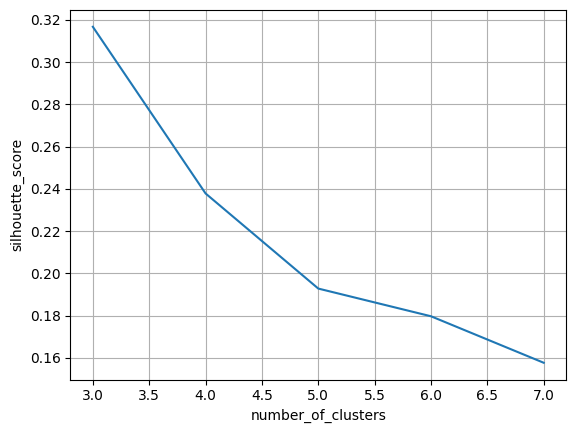

In [301]:
plt.plot(k_range,scores)
plt.xlabel('number_of_clusters')
plt.ylabel('silhouette_score')
plt.grid(True)
plt.show()

In [307]:
cluster_range = range(1,20)
cluster_error = []

for num_clusters in cluster_range:
  clusters = KMeans(n_clusters=num_clusters, random_state=123)
  clusters.fit(pca_model)
  cluster_error.append(clusters.inertia_)

In [309]:
clusters_df = pd.DataFrame({'cluster_range':cluster_range,'cluster_error':cluster_error})

In [310]:
clusters_df

,cluster_range,cluster_error
0,1,16348.792008
1,2,10548.455110
2,3,8922.037626
3,4,8352.591874
4,5,7406.867831
5,6,6919.498992
6,7,6511.903063
7,8,6133.066224
8,9,5941.868693
9,10,5757.908232


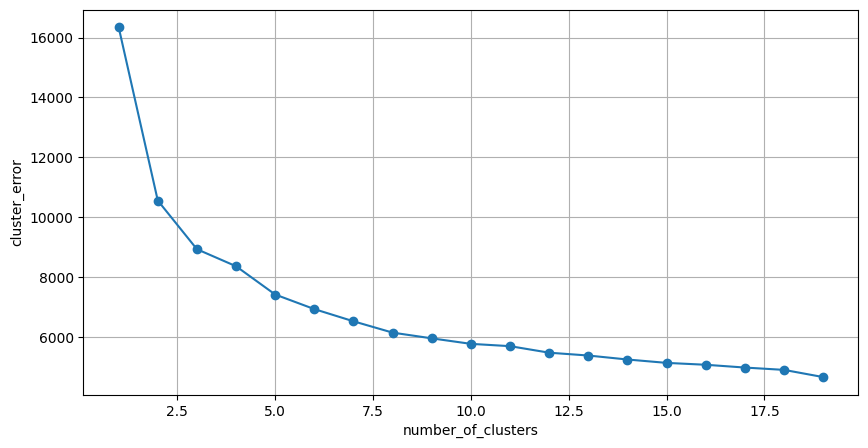

In [311]:
plt.figure(figsize=(10,5))
plt.plot(clusters_df['cluster_range'],clusters_df['cluster_error'],marker='o')
plt.xlabel('number_of_clusters')
plt.ylabel('cluster_error')
plt.grid(True)
plt.show()


In [312]:
# new data

In [ ]:
pca.transform(new_data)

In [ ]:
new_pca_model = pd.DataFrame(pca.transform(new_data),columns=['PC1','PC2','PC3','PC4','PC5','PC6','PC7','PC8','PC9','PC10'])

In [ ]:
k_mean_pca.predict(new_pca_model)

In [ ]:
new_pca_model['clusters'] = k_mean_pca.predict(new_pca_model)

In [313]:
# save it to destop